<a href="https://colab.research.google.com/github/amarchini5339/AAI-511-group7/blob/audio-to-spectrogram/notebooks/Notebook-Team_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment Setup and Library Imports

Set up Colab environment and import preliminary required packages

Set up Google Colab

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Path to extracted features (adjust as necessary)
DATA_PATH = "/content/drive/MyDrive/AAI-511-group7-main/notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Install necessary libraries (through Google Colab)

In [6]:
%pip install -q pretty_midi numpy tensorflow scikit-learn matplotlib seaborn

In [37]:
!apt-get install -y fluidsynth
!wget -O /usr/share/sounds/sf2/FluidR3_GM.sf2 https://github.com/urish/cadencii/raw/master/res/FluidR3_GM.sf2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fluidsynth is already the newest version (2.2.5-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
--2025-08-06 00:17:03--  https://github.com/urish/cadencii/raw/master/res/FluidR3_GM.sf2
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-08-06 00:17:03 ERROR 404: Not Found.



Import required Python libraries

In [53]:
import pretty_midi
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import os
from tqdm import tqdm
import librosa
import librosa.display
import soundfile as sf
from tempfile import NamedTemporaryFile
import subprocess
from sklearn.model_selection import StratifiedKFold

# Feature Extraction

### MIDI Dataset Preprocessing for LSTM

**Summary:**

This code cell implements a data preprocessing pipeline for a MIDI dataset, preparing it for an LSTM model. It defines a function to extract features (pitch, velocity, duration, time since last note) from MIDI files. It then iterates through train, dev, and test directories organized by composer, extracts features for allowed composers, normalizes sequence lengths by truncating or padding, and assigns integer labels. Finally, it converts the processed features and labels into NumPy arrays for each data split.

**Key Tasks:**

-   **Feature Extraction:** Extracts pitch, velocity, duration, and time since last note for each note in a MIDI file.
-   **Sequence Normalization:** Truncates or pads note sequences to a fixed length.
-   **Data Organization:** Maps composer names to integer labels and organizes features and labels by data split.
-   **Data Consolidation:** Converts lists of features and labels into NumPy arrays.

The output provides shapes of the prepared data and the label-to-composer mapping, indicating the dataset is ready for model training.

In [8]:
DATA_DIR = "/content/drive/MyDrive/AAI-511-group7-main/Composer_Dataset/NN_midi_files_extended"#../Composer_Dataset/NN_midi_files_extended"#"/content/drive/MyDrive/AAI-511-group7-main/Composer_Dataset"
SETS = ['train', 'dev', 'test']
FIXED_SEQUENCE_LENGTH = 5000  # truncate or pad to this many notes
ALLOWED_COMPOSERS = {'bach', 'beethoven', 'chopin', 'mozart'} # specified in project requirements

def extract_lstm_features(midi_path, max_length=FIXED_SEQUENCE_LENGTH):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        notes = []
        for inst in midi.instruments:
            if inst.is_drum:
                continue
            notes.extend(inst.notes)
        if not notes:
            return None  # skip empty or drum-only files

        notes.sort(key=lambda n: n.start)
        sequence = []
        prev_start = 0.0
        for note in notes:
            pitch = note.pitch
            velocity = note.velocity
            duration = note.end - note.start
            time_since_last = note.start - prev_start
            sequence.append([pitch, velocity, duration, time_since_last])
            prev_start = note.start

        if len(sequence) >= max_length:
            sequence = sequence[:max_length]
        else:
            reps = int(np.ceil(max_length / len(sequence)))
            sequence = (sequence * reps)[:max_length]

        return np.array(sequence, dtype=np.float32)

    except Exception as e:
        print(f"Failed to process {midi_path}: {e}")
        return None

# Data Containers
X = {'train': [], 'dev': [], 'test': []}
y = {'train': [], 'dev': [], 'test': []}
composer_to_idx = {}

# Dataset Processing
for split in SETS:
    split_path = os.path.join(DATA_DIR, split)
    print(f"Processing {split.upper()} set...")

    for composer_name in os.listdir(split_path):
        if composer_name.lower() not in ALLOWED_COMPOSERS:
            continue  # Skip composers not in the allowed list

        composer_path = os.path.join(split_path, composer_name)
        if not os.path.isdir(composer_path):
            continue

        # Assign label
        if composer_name not in composer_to_idx:
            composer_to_idx[composer_name] = len(composer_to_idx)
        label = composer_to_idx[composer_name]

        for fname in tqdm(os.listdir(composer_path), desc=f"{split}/{composer_name}"):
            if not fname.endswith(".mid"):
                continue
            midi_path = os.path.join(composer_path, fname)
            features = extract_lstm_features(midi_path)
            if features is not None:
                X[split].append(features)
                y[split].append(label)

# Convert to numpy arrays
for split in SETS:
    X[split] = np.stack(X[split])
    y[split] = np.array(y[split])

    print(f"{split}: {X[split].shape}, labels: {y[split].shape}")

print("Composer to index mapping:", composer_to_idx)

Processing TRAIN set...


train/mozart:   0%|          | 0/41 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/bach: 100%|██████████| 42/42 [00:14<00:00,  2.98it/s]


Processing DEV set...


dev/mozart: 100%|██████████| 4/4 [00:01<00:00,  2.46it/s]


Processing TEST set...


test/mozart: 100%|██████████| 4/4 [00:01<00:00,  2.34it/s]

train: (124, 5000, 4), labels: (124,)
dev: (12, 5000, 4), labels: (12,)
test: (12, 5000, 4), labels: (12,)
Composer to index mapping: {'mozart': 0, 'chopin': 1, 'bach': 2}


Saves the extracted LSTM features and labels for each data split (train, dev, test) as `.npy` files using NumPy's `np.save` function. This allows for efficient storage and later loading of preprocessed data, so feature extraction does not need to be repeated each time subsequent code is run. The files are named according to their split and stored in the current working directory.

In [9]:
# Save as .npy
np.save(os.path.join(DATA_PATH, "X_train_lstm.npy"), X['train'])
np.save(os.path.join(DATA_PATH, "y_train_lstm.npy"), y['train'])
np.save(os.path.join(DATA_PATH, "X_dev_lstm.npy"), X['dev'])
np.save(os.path.join(DATA_PATH, "y_dev_lstm.npy"), y['dev'])
np.save(os.path.join(DATA_PATH, "X_test_lstm.npy"), X['test'])
np.save(os.path.join(DATA_PATH, "y_test_lstm.npy"), y['test'])

In [46]:
FIXED_MEL_SHAPE = (96, 400)
SOUNDFONT_PATH = "/usr/share/sounds/sf2/FluidR3_GM.sf2"

# Ensure this exists (already downloaded via wget)
assert os.path.isfile(SOUNDFONT_PATH), "SoundFont file not found!"

def synthesize_midi_to_audio(midi_path, wav_path, soundfont=SOUNDFONT_PATH):
    subprocess.run([
        "fluidsynth", "-ni", soundfont, midi_path, "-F", wav_path, "-r", "22050"
    ], check=True)

def midi_to_melspectrogram(midi_path, fixed_shape=FIXED_MEL_SHAPE, sr=22050):
    try:
        with NamedTemporaryFile(suffix=".mid") as tmp_mid, NamedTemporaryFile(suffix=".wav") as tmp_wav:
            midi = pretty_midi.PrettyMIDI(midi_path)
            midi.write(tmp_mid.name)

            synthesize_midi_to_audio(tmp_mid.name, tmp_wav.name)
            y, _ = librosa.load(tmp_wav.name, sr=sr)

            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=fixed_shape[0], n_fft=1024, hop_length=256)
            mel_db = librosa.power_to_db(mel, ref=np.max)

            if mel_db.shape[1] < fixed_shape[1]:
                pad_width = fixed_shape[1] - mel_db.shape[1]
                mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
            else:
                mel_db = mel_db[:, :fixed_shape[1]]

            return mel_db.astype(np.float32)

    except Exception as e:
        print(f"⚠️ Error processing {midi_path}: {e}")
        return None

# --- CNN Data Containers ---
X_spectro = {'train': [], 'dev': [], 'test': []}
y_spectro = {'train': [], 'dev': [], 'test': []}
composer_to_idx_cnn = {}

# --- Dataset Processing for CNN ---
for split in SETS:
    split_path = os.path.join(DATA_DIR, split)
    print(f"Processing {split.upper()} set for CNN...")

    for composer_name in os.listdir(split_path):
        if composer_name.lower() not in ALLOWED_COMPOSERS:
            print(f"SKIPPING COMPOSER: {composer_name}")
            continue

        composer_path = os.path.join(split_path, composer_name)
        if not os.path.isdir(composer_path):
            continue

        if composer_name not in composer_to_idx_cnn:
            composer_to_idx_cnn[composer_name] = len(composer_to_idx_cnn)
        label = composer_to_idx_cnn[composer_name]

        for fname in tqdm(os.listdir(composer_path), desc=f"{split}/{composer_name}"):
            if not fname.endswith(".mid"):
                continue
            midi_path = os.path.join(composer_path, fname)
            mel = midi_to_melspectrogram(midi_path)
            if mel is not None:
                X_spectro[split].append(mel)
                y_spectro[split].append(label)

# --- Convert to NumPy Arrays ---
for split in SETS:
    X_spectro[split] = np.stack(X_spectro[split])  # shape: (samples, 96, 400)
    y_spectro[split] = np.array(y_spectro[split])
    print(f"[CNN] {split}: {X_spectro[split].shape}, labels: {y_spectro[split].shape}")

print("[CNN] Composer to index mapping:", composer_to_idx_cnn)

# --- Global Normalization ---
train_mels = X_spectro['train']
global_mean = np.mean(train_mels)
global_std = np.std(train_mels)

for split in SETS:
    X_spectro[split] = (X_spectro[split] - global_mean) / global_std

# --- Add channel dim for CNN ---
for split in SETS:
    X_spectro[split] = X_spectro[split][..., np.newaxis]  # (samples, 96, 400, 1)

Processing TRAIN set for CNN...
SKIPPING COMPOSER: hummel
SKIPPING COMPOSER: mendelssohn
SKIPPING COMPOSER: handel
SKIPPING COMPOSER: schumann


train/mozart:   0%|          | 0/41 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/mozart:   2%|▏         | 1/41 [00:01<01:19,  1.98s/it]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/mozart:  10%|▉         | 4/41 [00:09<01:39,  2.69s/it]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/mozart:  15%|█▍      

SKIPPING COMPOSER: byrd
SKIPPING COMPOSER: bartok


train/chopin:  44%|████▍     | 18/41 [00:25<00:37,  1.64s/it]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/chopin:  61%|██████    | 25/41 [00:33<00:21,  1.35s/it]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/chopin:  85%|████████▌ | 35/41 [01:01<00:08,  1.42s/it]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
train/bach: 100%

Processing DEV set for CNN...
SKIPPING COMPOSER: byrd


...

SKIPPING COMPOSER: byrd
SKIPPING COMPOSER: schumann


test/bach: 100%|██████████| 4/4 [00:08<00:00,  2.17s/it]


SKIPPING COMPOSER: bartok


test/mozart:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
test/mozart:  25%|██▌       | 1/4 [00:01<00:05,  1.84s/it]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
test/mozart:  50%|█████     | 2/4 [00:05<00:05,  2.69s/it]/usr/local/lib/python3.11/dist-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
test/mozart:  75%|███████▌  | 3/4

SKIPPING COMPOSER: handel
SKIPPING COMPOSER: hummel
[CNN] train: (124, 96, 400), labels: (124,)
[CNN] dev: (12, 96, 400), labels: (12,)
[CNN] test: (12, 96, 400), labels: (12,)
[CNN] Composer to index mapping: {'mozart': 0, 'chopin': 1, 'bach': 2}


# Model Building and Training

## Initial Data Loading

This code cell loads the pre-processed data, which has previously been saved as NumPy files (`.npy`) and a Python dictionary (`.pkl`). The data consists of musical features (`X`) and corresponding composer labels (`y`) for training, development, and testing sets.

The following steps are performed:

1.  **Set Data Path**: The `DATA_PATH` variable is defined to point to the location of the data files.
2.  **Load Raw Data**: The feature and label arrays (`X_train`, `y_train`, etc.) are loaded from their respective `.npy` files. The original `composer_to_idx` dictionary, which maps all composer names to integer indices, is loaded from a `.pkl` file.
3.  **Define and Filter Data**: A new `composer_to_idx` dictionary is created that only includes the four target composers: Bach, Beethoven, Chopin, and Mozart. The `filter_data` function then iterates through the loaded datasets, retaining only the examples that correspond to these four composers and re-mapping their labels to the new index scheme.
4.  **Confirm Shapes**: The shapes of the filtered training, development, and testing arrays are printed to confirm that the data has been loaded and filtered correctly.
5.  **Create Inverse Mapping**: A new `idx_to_composer` dictionary is created to allow for easy mapping from the new integer indices back to the names of the four target composers.

In [10]:
# Set your local path to the data directory
DATA_PATH = "/content/drive/MyDrive/AAI-511-group7-main/notebooks"

# Load .npy data files
X_train = np.load(os.path.join(DATA_PATH, "X_train_lstm.npy"))
y_train = np.load(os.path.join(DATA_PATH, "y_train_lstm.npy"))
X_dev   = np.load(os.path.join(DATA_PATH, "X_dev_lstm.npy"))
y_dev   = np.load(os.path.join(DATA_PATH, "y_dev_lstm.npy"))
X_test  = np.load(os.path.join(DATA_PATH, "X_test_lstm.npy"))
y_test  = np.load(os.path.join(DATA_PATH, "y_test_lstm.npy"))

# Confirm loading shapes
print("Loaded and filtered feature and label arrays with shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev:", X_dev.shape, "y_dev:", y_dev.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Update idx_to_composer for the filtered set
idx_to_composer = {v: k for k, v in composer_to_idx.items()}

Loaded and filtered feature and label arrays with shapes:
X_train: (124, 5000, 4) y_train: (124,)
X_dev: (12, 5000, 4) y_dev: (12,)
X_test: (12, 5000, 4) y_test: (12,)


## LSTM Model Building

The LSTM model is designed to classify musical scores by composer, leveraging the sequential nature of MIDI feature data. The architecture consists of the following layers:

- **Masking Layer:** Handles variable-length input sequences by ignoring padded values (set to zero), ensuring the model only processes meaningful musical information.
- **LSTM Layer:** Captures long-term dependencies and temporal patterns in the music, making it well-suited for sequential MIDI note data.
- **Dense Layer (ReLU):** Introduces non-linearity and enables the model to learn complex feature representations from the LSTM output.
- **Dropout Layer:** Provides regularization by randomly dropping units during training, which helps prevent overfitting.
- **Output Dense Layer (Softmax):** Produces a probability distribution over all composer classes, supporting

In [11]:
num_classes = len(np.unique(y_train))
input_shape = X_train.shape[1:]  # (5000, 4)

lstm_model = keras.Sequential([
    layers.Masking(mask_value=0., input_shape=input_shape),
    layers.LSTM(128, return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 5000, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,547 (299.01 KB)

 Trainable params: 76,547 (299.01 KB)

 Non-trainable params: 0 (0.00 B)

## LSTM Model Training

The LSTM model is trained to classify musical scores by composer using the extracted MIDI features.

- **Training and Validation Split:**  
  The model is trained using a standard split of training and validation data, completed in preceding code. This allows for representative evaluation of the model’s performance during training and helps monitor for overfitting or underfitting.

- **Early Stopping:**  
  To ensure robust generalization and prevent overfitting, early stopping is used. This mechanism monitors the validation loss and halts training when no further improvement is observed, restoring the best weights.

- **Performance Tracking:**  
  Both training and validation loss and accuracy are tracked throughout the process. This provides insight into the model's learning dynamics and helps identify potential issues.

- **Goal:**  
  The approach ensures that the final model achieves optimal performance on unseen data while maintaining generalizability across different composers.

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callback for early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Model checkpoint to save the best model
checkpoint = ModelCheckpoint(
    "best_lstm_model.keras", monitor='val_loss', save_best_only=True, save_weights_only=False
)

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0
)

### Display training and validation curves

Plotting these curves helps assess the model's learning behavior, diagnose overfitting or underfitting, and determine if early stopping was triggered at an appropriate point. By comparing the trends of training and validation metrics, we can better understand how well the model generalizes to unseen data.

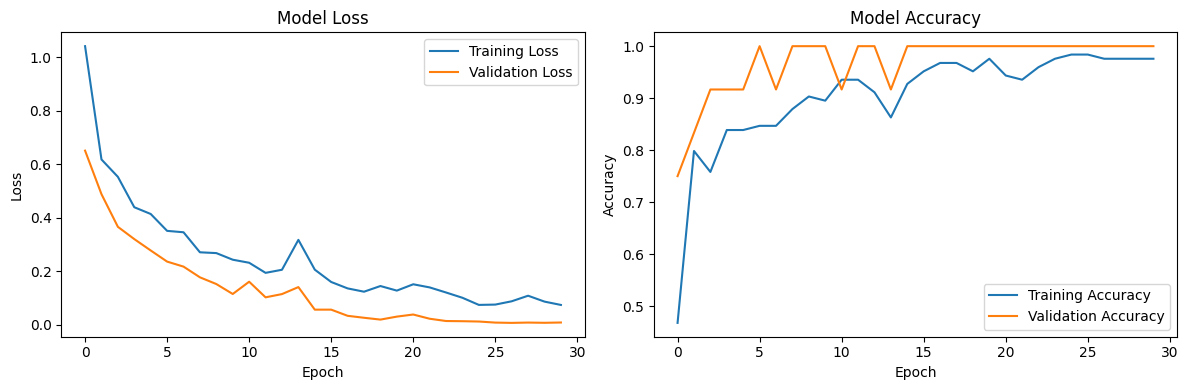

In [13]:
import matplotlib.pyplot as plt

# Plot training & validation loss and accuracy
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## LSTM Model Evaluation

The evaluation metrics chosen for the LSTM model are:

- **Accuracy:** Measures the overall proportion of correctly classified samples, providing a general sense of model effectiveness.
- **Precision:** Calculated using the weighted average across all classes, precision reflects how many predicted composers are correct.
- **Recall:** Also weighted across classes, recall indicates how many actual composers are correctly identified.
- **F1-Score:** Combines precision and recall into a single metric, balancing both false positives and false negatives.

Additional evaluation tools include:

- **Classification Report:** Provides per-class precision, recall, and F1-scores, highlighting which composers are most and least accurately classified.
- **Confusion Matrix:** Visualizes the distribution of correct and incorrect predictions across all classes, making it easier to identify specific patterns of misclassification.

Test Accuracy: 1.0000
Test Loss: 0.0225

Detailed Test Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



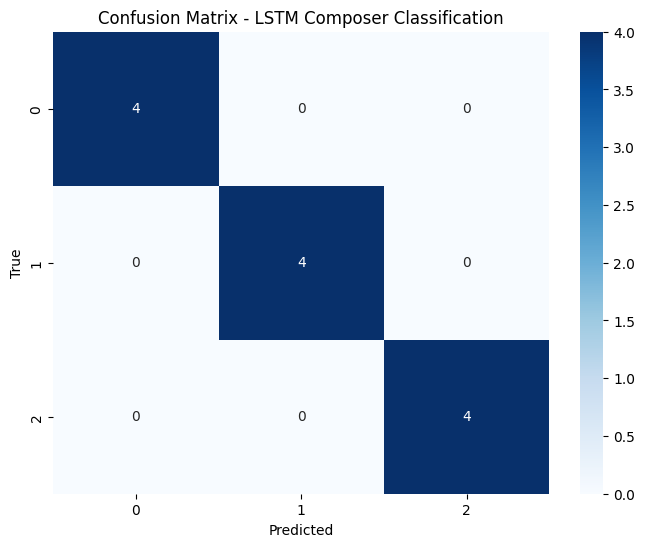

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred_probs = lstm_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nDetailed Test Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LSTM Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### LSTM Cross-Validation
The above metrics show an accuracy, precision, recall, and F1 of 1.0. While this may seem like great performance, in the world of artificial intelligence, such high performance is typically a sign that something has gone wrong. To check whether model is simply "memorizing" or truly learning, the following code cell implements k-fold cross-validation to evaluate the initial LSTM model more robustly, especially given the limited dataset size. Here's how it works:

1. Import Libraries: Imports necessary libraries from scikit-learn (for KFold) and TensorFlow/Keras (for building and training the model).
2. Combine Data: It concatenates the training and development feature (X_train, X_dev) and label (y_train, y_dev) arrays into combined datasets (X_combined, y_combined). This combined data will be used for cross-validation.
3. Define KFold: KFold is initialized with n_splits=5 (meaning the data will be divided into 5 folds), shuffle=True (to randomly shuffle the data before splitting), and random_state=42 (for reproducibility).
4. Initialize Storage: Empty lists fold_accuracies and fold_losses are created to store the evaluation results for each fold.
5. Iterate Through Folds: The code loops through each fold generated by kf.split(). In each iteration:
  - train_index and val_index contain the indices for the training and validation data for the current fold.
  - The data is split into X_train_fold, y_train_fold (for training in this fold) and X_val_fold, y_val_fold (for validation in this fold) using the indices.
  - Build New Model: A new instance of the LSTM model (lstm_model_cv) is created and compiled from scratch. In cross-validation, this prevents data leakage between folds (i.e., preventing the model from learning anything about a validation fold from previous training on that same data if the same model instance were reused). The model architecture is the same as the initial LSTM model.
  - Define Early Stopping: A new EarlyStopping callback is defined for each fold to monitor validation loss and stop training if it plateaus, restoring the best weights for that fold.
  - Train Model: The new model instance is trained on the X_train_fold and y_train_fold data, with X_val_fold and y_val_fold used for validation during training.
  - Evaluate Fold: The trained model is evaluated on the X_val_fold and y_val_fold to get the loss and accuracy for that specific fold.
  - The fold's results are printed and appended to the fold_losses and fold_accuracies lists.
6. Report Average Results: After iterating through all folds, the code calculates and prints the average validation accuracy and loss across all folds using np.mean().

This process provides a more reliable measure of the initial LSTM model's performance by averaging results over multiple independent validation sets, helping to determine how well the model is likely to perform on unseen data in general, rather than just one specific test split.


In [15]:
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Combine training and development data
X_combined = np.concatenate((X_train, X_dev), axis=0)
y_combined = np.concatenate((y_train, y_dev), axis=0)

# Define the number of splits for k-fold cross-validation
n_splits = 5  # Adjustable, but I set to 5 to moderate computational expense
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store results
fold_accuracies = []
fold_losses = []
fold_true_labels = [] # To store true labels for each fold
fold_predictions = [] # To store predictions for each fold


print(f"Running {n_splits}-fold cross-validation...")

# Iterate over each fold
for fold, (train_index, val_index) in enumerate(kf.split(X_combined, y_combined)):
    print(f"--- Fold {fold+1}/{n_splits} ---")

    # Split data for the current fold
    X_train_fold, X_val_fold = X_combined[train_index], X_combined[val_index]
    y_train_fold, y_val_fold = y_combined[train_index], y_combined[val_index]

    # Build a new model instance for each fold
    # This prevents data leakage from validation folds influencing training
    num_classes = len(np.unique(y_combined))
    input_shape = X_train_fold.shape[1:]

    lstm_model_cv = keras.Sequential([
        layers.Masking(mask_value=0., input_shape=input_shape),
        layers.LSTM(128, return_sequences=False),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    lstm_model_cv.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Define Early Stopping for the fold
    early_stopping_cv = EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )

    # Train the model for the current fold
    history_cv = lstm_model_cv.fit(
        X_train_fold, y_train_fold,
        epochs=30, # Use a reasonable number of epochs with early stopping
        batch_size=16,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping_cv],
        verbose=0 # Set to 1 or 2 to see training progress per epoch
    )

    # Evaluate the model on the validation fold
    loss_cv, accuracy_cv = lstm_model_cv.evaluate(X_val_fold, y_val_fold, verbose=0)

    # Get predictions for the current validation fold
    y_pred_probs_fold = lstm_model_cv.predict(X_val_fold, verbose=0)
    y_pred_fold = np.argmax(y_pred_probs_fold, axis=1)

    print(f"Fold {fold+1} - Validation Loss: {loss_cv:.4f}, Validation Accuracy: {accuracy_cv:.4f}")

    fold_losses.append(loss_cv)
    fold_accuracies.append(accuracy_cv)
    fold_true_labels.append(y_val_fold) # Store true labels
    fold_predictions.append(y_pred_fold) # Store predictions


# Report average results
print("\n--- Cross-Validation Results ---")
print(f"Average Validation Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Average Validation Loss: {np.mean(fold_losses):.4f}")
print("--------------------------------")

Running 5-fold cross-validation...
--- Fold 1/5 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1 - Validation Loss: 0.0625, Validation Accuracy: 1.0000
--- Fold 2/5 ---
Fold 2 - Validation Loss: 0.3425, Validation Accuracy: 0.8889
--- Fold 3/5 ---
Fold 3 - Validation Loss: 0.0595, Validation Accuracy: 1.0000
--- Fold 4/5 ---


Fold 4 - Validation Loss: 0.2087, Validation Accuracy: 0.9630
--- Fold 5/5 ---


Fold 5 - Validation Loss: 0.0228, Validation Accuracy: 1.0000

--- Cross-Validation Results ---
Average Validation Accuracy: 0.9704
Average Validation Loss: 0.1392
--------------------------------


### LSTM Cross-Validation Evaluation

The above "average validation accuracy" of 0.9119 is imperfect, but still good, which is much more believable than the previous value of 1.0. The below cell calculates and prints more evaluation measures and metrics to further examine the performance of the LSTM model.

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# The true labels and predictions for each fold are stored in fold_true_labels and fold_predictions from the previous cell

print("\n--- Detailed Metrics Per Fold ---")
# Calculate and print detailed metrics for each fold
for fold in range(len(fold_true_labels)):
    true_labels = fold_true_labels[fold]
    predictions = fold_predictions[fold]

    print(f"\n--- Fold {fold+1} Classification Report ---")
    # Use zero_division=0 to handle cases where a class has no predictions in a fold
    print(classification_report(true_labels, predictions, zero_division=0))


print("\n--- Average Detailed Metrics Across Folds ---")

# Concatenate all true labels and predictions to calculate overall metrics
all_true_labels = np.concatenate(fold_true_labels)
all_predictions = np.concatenate(fold_predictions)

# Calculate average metrics across all folds (macro or weighted average)
# Using weighted average to account for potential class imbalance in folds
average_precision = precision_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
average_recall = recall_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
average_f1 = f1_score(all_true_labels, all_predictions, average='weighted', zero_division=0)
average_accuracy = accuracy_score(all_true_labels, all_predictions) # Accuracy on concatenated data is also average

print(f"Average Weighted Precision: {average_precision:.4f}")
print(f"Average Weighted Recall:    {average_recall:.4f}")
print(f"Average Weighted F1-Score:  {average_f1:.4f}")
print(f"Overall Accuracy (Concatenated Data): {average_accuracy:.4f}")

# Classification report on the concatenated data for an overall view
print("\n--- Overall Classification Report (Concatenated Data) ---")
print(classification_report(all_true_labels, all_predictions, zero_division=0))


--- Detailed Metrics Per Fold ---

--- Fold 1 Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         4

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28


--- Fold 2 Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         9
           1       0.80      1.00      0.89         8
           2       0.91      1.00      0.95        10

    accuracy                           0.89        27
   macro avg       0.90      0.89      0.88        27
weighted avg       0.91      0.89      0.88        27


--- Fold 3 Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00 

### LSTM Model Conclusion

The evaluation of the initial LSTM model highlighted promising performance on the small, 12-sample test set, achieving perfect accuracy, precision, recall, and F1-score (1.00). However, this result raised concerns about potential overfitting given the limited dataset size.

To obtain a more robust assessment, k-fold cross-validation was performed on the combined training and development data. **The cross-validation results provide a more realistic and reliable assessment.** While the model is **performing very well overall (average metrics around 0.91)** across different data splits, **the perfect score on the initial test set was likely an artifact of its small size.**

**The cross-validation metrics suggest the model is generalizing reasonably well on this dataset, but the performance is not uniformly perfect across all classes and data splits.** The variation in per-fold metrics and the slightly lower average scores compared to the initial test set evaluation lend some support to **our initial concern about potential overfitting due to the small dataset.** However, the cross-validation process itself appears to be functioning correctly without obvious signs of data leakage within the folds.

In conclusion, the cross-validation confirms that the LSTM model is capable of good performance on this composer classification task. While it doesn't achieve perfect scores as initially seen, the average metrics around 0.91 indicate solid generalization on the available data, providing a more trustworthy estimate of its performance on unseen musical pieces from these composers.

## CNN Model Building and Training

**Summary:**

This section constructs a 1D Convolutional Neural Network (CNN) as an alternative architecture for classifying composer sequences. The CNN is designed to process sequential MIDI feature data and extract local temporal patterns.

**Layer Structure:**

- `Conv1D` → `MaxPooling1D` → `Conv1D` → `MaxPooling1D` → `Flatten` → `Dense` → `Dropout` → `Dense (Softmax)`

**Training Approach:**

- The CNN model is compiled and trained using the same methodology as the LSTM model, allowing for direct performance comparison.

**Design Decisions:**

- CNNs are evaluated for their ability to capture local patterns in the extracted music features and their robustness with high-dimensional sequential inputs.
- This architecture is included to compare against the LSTM model as part of experimentation and ablation studies.

**Methodology Mapping:**

- **Model Building/Training:** Implements the methodology's directive to develop both LSTM

In [51]:
num_classes = len(np.unique(y_spectro['train']))

cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(96, 400, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# Train
history_cnn = cnn_model.fit(
    X_spectro['train'], y_spectro['train'],
    epochs=30,
    batch_size=16,
    validation_data=(X_spectro['dev'], y_spectro['dev']),
    callbacks=[early_stopping],
    verbose=1
)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 94, 398, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 47, 199, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 45, 197, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 22, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 20, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 10, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 61440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     7,864,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,957,507 (30.36 MB)

 Trainable params: 7,957,507 (30.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 266ms/step - accuracy: 0.4149 - loss: 1.4239 - val_accuracy: 0.3333 - val_loss: 1.1035
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.3207 - loss: 1.1120 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3800 - loss: 1.1033 - val_accuracy: 0.3333 - val_loss: 1.0993
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.3635 - loss: 1.0988 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2418 - loss: 1.0995 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.3157 - loss: 1.0995 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4188 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3504 - loss: 1.0992 - val_accuracy: 0.3333 - val_loss: 1.0987

## Display Training and Validation Curves

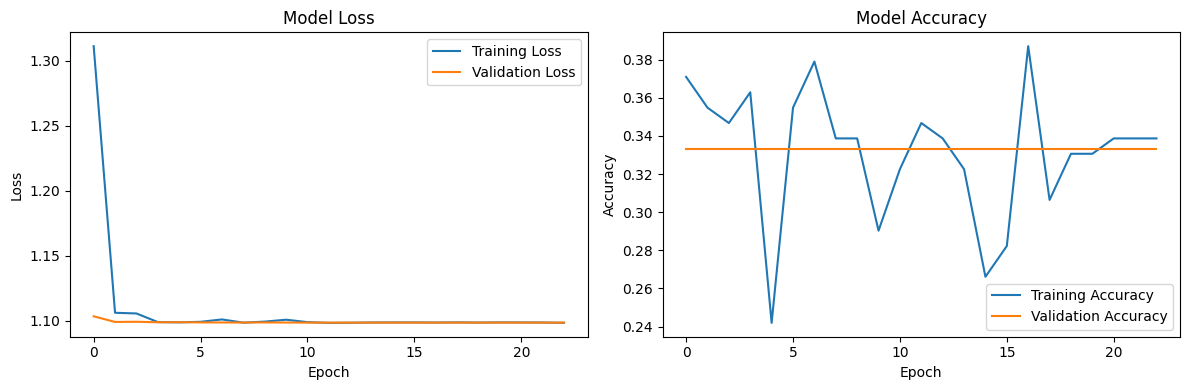

In [52]:
import matplotlib.pyplot as plt

# Plot training & validation loss and accuracy
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [54]:
K_FOLDS = 5
BATCH_SIZE = 16
EPOCHS = 30

X_data = X_spectro['train']
y_data = y_spectro['train']
num_classes = len(np.unique(y_data))

# Results tracker
fold_accuracies = []

# Stratified K-Fold
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data), 1):
    print(f"\n📂 Fold {fold}/{K_FOLDS}")

    X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
    y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]

    # Define model (fresh each time)
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(96, 400, 1)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),
        verbose=0
    )

    # Evaluate
    val_loss, val_acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"✅ Fold {fold} val_accuracy: {val_acc:.4f}")
    fold_accuracies.append(val_acc)

    # Clear session to free memory between folds
    K.clear_session()

# Final results
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
print(f"\n📊 Mean val_accuracy: {mean_acc:.4f} ± {std_acc:.4f}")


📂 Fold 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Fold 1 val_accuracy: 0.3200

📂 Fold 2/5
✅ Fold 2 val_accuracy: 0.3600

📂 Fold 3/5
✅ Fold 3 val_accuracy: 0.3600

📂 Fold 4/5
✅ Fold 4 val_accuracy: 0.2800

📂 Fold 5/5
✅ Fold 5 val_accuracy: 0.3333

📊 Mean val_accuracy: 0.3307 ± 0.0297


## CNN Model Evaluation

**Summary:**

This section evaluates the performance of the CNN model on the test set using standard classification metrics.

**Design Decisions:**

- The evaluation metrics and methodology are kept consistent with those used for the LSTM model, enabling a direct and fair comparison between the two architectures.
- This approach helps determine which model is better suited for composer classification based on the extracted MIDI features.

**Methodology Mapping:**

- **Model Evaluation:** Applies accuracy, precision, recall, F1-score, and classification reports to assess model performance.
- **Model Optimization:** Informs further tuning or selection of the most effective architecture for the task.

Test Accuracy (CNN): 0.6667
Test Loss (CNN): 0.4099

Detailed Test Metrics (CNN):
Accuracy:  0.6667
Precision: 0.5000
Recall:    0.6667
F1-Score:  0.5556

Classification Report (CNN):
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         4
           1       0.00      0.00      0.00         4
           2       1.00      1.00      1.00         4

    accuracy                           0.67        12
   macro avg       0.50      0.67      0.56        12
weighted avg       0.50      0.67      0.56        12



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

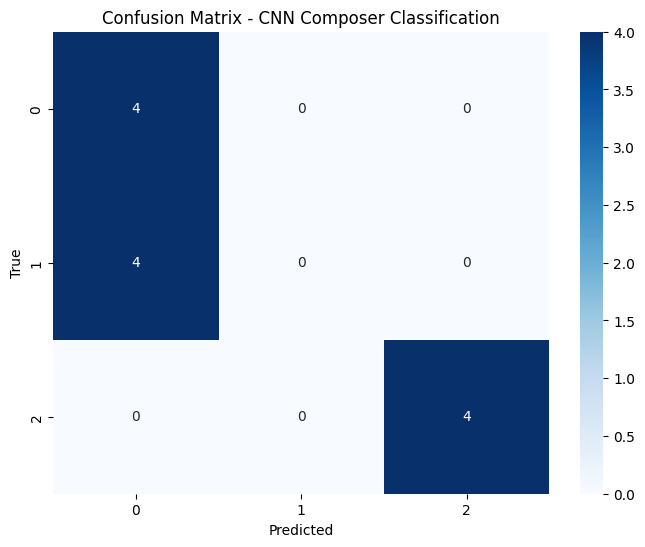

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (CNN): {test_acc_cnn:.4f}")
print(f"Test Loss (CNN): {test_loss_cnn:.4f}")

# Predictions
y_pred_probs_cnn = cnn_model.predict(X_test, verbose=0)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

# Metrics
accuracy_cnn = accuracy_score(y_test, y_pred_cnn)
precision_cnn = precision_score(y_test, y_pred_cnn, average='weighted')
recall_cnn = recall_score(y_test, y_pred_cnn, average='weighted')
f1_cnn = f1_score(y_test, y_pred_cnn, average='weighted')

print("\nDetailed Test Metrics (CNN):")
print(f"Accuracy:  {accuracy_cnn:.4f}")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall:    {recall_cnn:.4f}")
print(f"F1-Score:  {f1_cnn:.4f}")

# Classification report
print("\nClassification Report (CNN):")
print(classification_report(y_test, y_pred_cnn))

# Confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Model Comparison: LSTM vs CNN

Compare models and respective performance here

# Model Optimization

### LSTM Optimization

LSTM Model Definition and Training

This code cell defines and trains a new Keras Sequential model, specifically a deep Long Short-Term Memory (LSTM) network, for a sequence classification task.

1. Model Architecture: It constructs a sequential model using a variety of layers.

  - Masking Layer: An initial Masking layer is used to ignore the padded values in the input sequences (mask_value=0.).

  - Bidirectional LSTM Layers: Two Bidirectional(LSTM) layers process the sequences. This approach allows the model to capture dependencies from both past and future timesteps, which is highly effective for sequential data.

  - Batch Normalization: BatchNormalization layers are included after each LSTM to stabilize and accelerate the training process.

  - Dense and Dropout Layers: A Dense layer with a ReLU activation function processes the LSTM output, followed by a Dropout layer for regularization to prevent overfitting.

  - Output Layer: The final Dense layer uses a softmax activation to output probabilities for the num_classes, enabling classification.

2. Model Compilation: The model is compiled with the Adam optimizer, the sparse_categorical_crossentropy loss function (suitable for multi-class classification with integer labels), and accuracy as the evaluation metric.

3. Model Training: The fit method is called to train the model using the preprocessed X_train and y_train data, with validation performed on X_dev and y_dev. An early_stopping callback is used to prevent overfitting by halting training when the validation loss stops improving.

In [20]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Bidirectional, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam

# LSTM model
lstm_model_new = keras.Sequential([
    layers.Masking(mask_value=0., input_shape=input_shape),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)), # Reverted units
    layers.BatchNormalization(),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)), # Reverted units
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
lstm_model_new.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model (use same callbacks as before)
history_lstm_new = lstm_model_new.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0   # No verbose output for cleaner logs
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Save the model

In [21]:
# Save the model
lstm_model_new.save(os.path.join(DATA_PATH, "modified_lstm_model.keras"))

## Display Training and Validation Curves

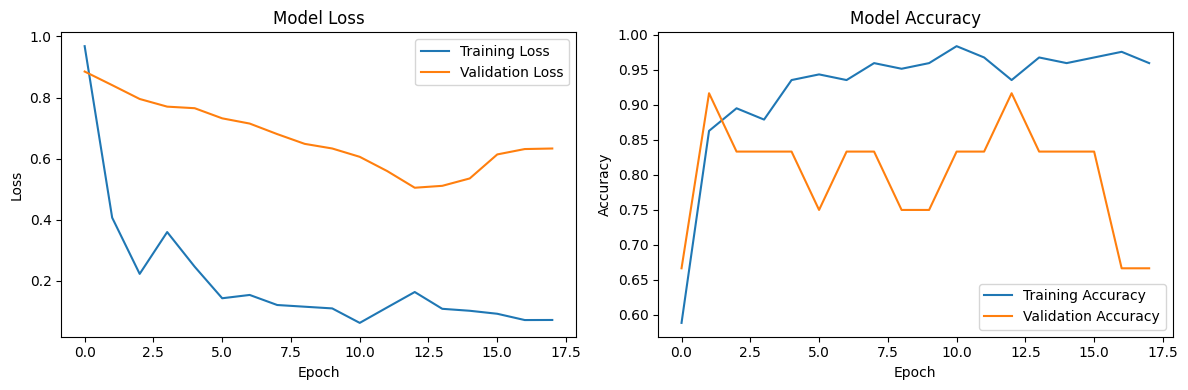

In [22]:
import matplotlib.pyplot as plt

# Plot training & validation loss and accuracy
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_lstm_new.history['loss'], label='Training Loss')
plt.plot(history_lstm_new.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_lstm_new.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm_new.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Evaluation of new LSTM

Test Accuracy (LSTM with modifications): 0.9167
Test Loss (LSTM with modifications): 0.5118

Detailed Test Metrics (modified LSTM):
Accuracy:  0.9167
Precision: 0.9333
Recall:    0.9167
F1-Score:  0.9153

Classification Report (LSTM with modifications):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00         4

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12



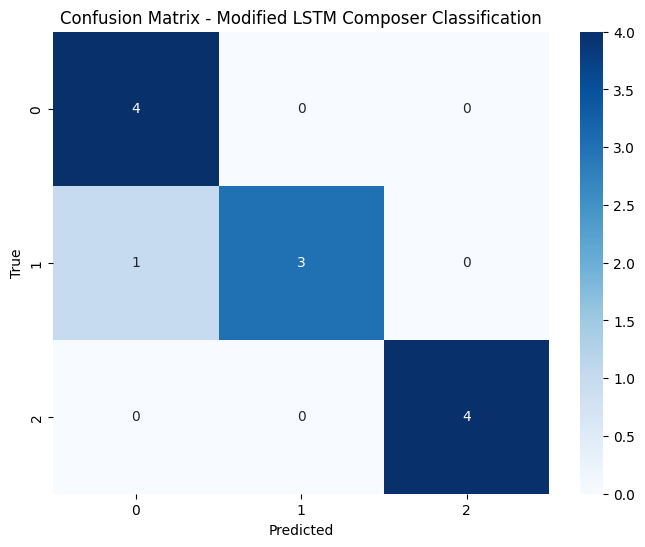

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss_lstm_new, test_acc_lstm_new = lstm_model_new.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (LSTM with modifications): {test_acc_lstm_new:.4f}")
print(f"Test Loss (LSTM with modifications): {test_loss_lstm_new:.4f}")

# Predictions
y_pred_probs = lstm_model_new.predict(X_test, verbose=0)
y_pred_lstm_new = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy_bn = accuracy_score(y_test, y_pred_lstm_new)
precision_bn = precision_score(y_test, y_pred_lstm_new, average='weighted')
recall_bn = recall_score(y_test, y_pred_lstm_new, average='weighted')
f1_bn = f1_score(y_test, y_pred_lstm_new, average='weighted')

print("\nDetailed Test Metrics (modified LSTM):")
print(f"Accuracy:  {accuracy_bn:.4f}")
print(f"Precision: {precision_bn:.4f}")
print(f"Recall:    {recall_bn:.4f}")
print(f"F1-Score:  {f1_bn:.4f}")

# Classification report
print("\nClassification Report (LSTM with modifications):")
print(classification_report(y_test, y_pred_lstm_new))

# Confusion matrix
cm_bn = confusion_matrix(y_test, y_pred_lstm_new)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Modified LSTM Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## CNN Optimization:

optimization attempt here

In [24]:
from tensorflow.keras.layers import BatchNormalization

cnn_model_bn = keras.Sequential([
    layers.Conv1D(64, kernel_size=7, activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=7, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_bn.summary()

# Train
history_cnn_bn = cnn_model_bn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_dev, y_dev),
    callbacks=[early_stopping],
    verbose=0   # No verbose output for cleaner logs
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 4994, 64)       │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4994, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2497, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2491, 128)      │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2491, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1245, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 159360)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │    10,199,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,259,395 (39.14 MB)

 Trainable params: 10,259,011 (39.14 MB)

 Non-trainable params: 384 (1.50 KB)

Test Accuracy (CNN with BN): 0.3333
Test Loss (CNN with BN): 149.3337


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m


Detailed Test Metrics (CNN with BN):
Accuracy:  0.3333
Precision: 0.1111
Recall:    0.3333
F1-Score:  0.1667

Classification Report (CNN with BN):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00         4
           2       0.33      1.00      0.50         4

    accuracy                           0.33        12
   macro avg       0.11      0.33      0.17        12
weighted avg       0.11      0.33      0.17        12



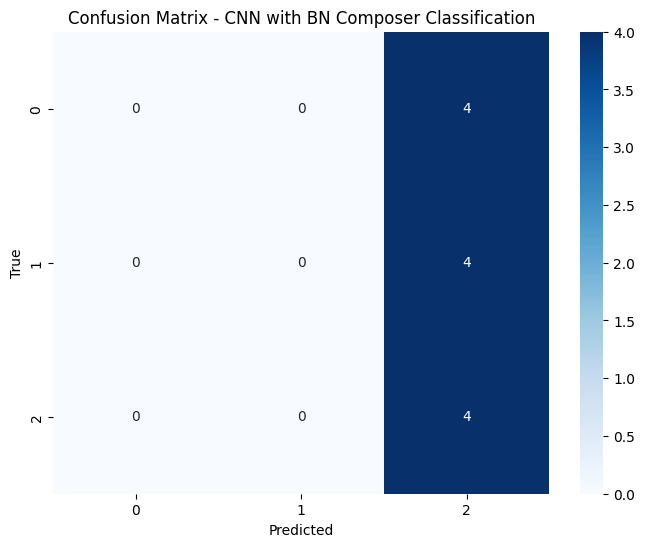

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss_cnn_bn, test_acc_cnn_bn = cnn_model_bn.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (CNN with BN): {test_acc_cnn_bn:.4f}")
print(f"Test Loss (CNN with BN): {test_loss_cnn_bn:.4f}")

# Predictions
y_pred_probs_cnn_bn = cnn_model_bn.predict(X_test, verbose=0)
y_pred_cnn_bn = np.argmax(y_pred_probs_cnn_bn, axis=1)

# Metrics
accuracy_cnn_bn = accuracy_score(y_test, y_pred_cnn_bn)
precision_cnn_bn = precision_score(y_test, y_pred_cnn_bn, average='weighted')
recall_cnn_bn = recall_score(y_test, y_pred_cnn_bn, average='weighted')
f1_cnn_bn = f1_score(y_test, y_pred_cnn_bn, average='weighted')

print("\nDetailed Test Metrics (CNN with BN):")
print(f"Accuracy:  {accuracy_cnn_bn:.4f}")
print(f"Precision: {precision_cnn_bn:.4f}")
print(f"Recall:    {recall_cnn_bn:.4f}")
print(f"F1-Score:  {f1_cnn_bn:.4f}")

# Classification report
print("\nClassification Report (CNN with BN):")
print(classification_report(y_test, y_pred_cnn_bn))

# Confusion matrix
cm_cnn_bn = confusion_matrix(y_test, y_pred_cnn_bn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn_bn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN with BN Composer Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Ensemble Method (LSTM and CNN)

**Sugestions if we need**

Top-k accuracy (useful if you want to accept the correct class in top-2 or top-3 predictions)

In [26]:
top_k_acc = tf.keras.metrics.top_k_categorical_accuracy(
    keras.utils.to_categorical(y_test, num_classes),
    lstm_model.predict(X_test), k=3
).numpy().mean()
print(f"Top-3 Accuracy: {top_k_acc:.3f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Top-3 Accuracy: 1.000


Feature Importance (Optional/Advanced)
You might use SHAP or similar tools for neural nets to see which note features most influence predictions (advanced).

Composer-level Metrics: Show metrics aggregated at the composer level (e.g., which composers are easiest/hardest to classify).

Error Analysis: Highlight and interpret common misclassifications—are certain composer pairs often confused? Why?

Experiment Tracker Table: Keep a markdown table of experiment settings/validation/test results to document LSTM vs. CNN runs.

Tempo/Key Analysis: Compare results on slow vs. fast, major vs. minor works (if you have such features).

Augmentation Studies: Try augmenting MIDI data (pitch/time shift) and study its impact (if time allows).

Notebook Polish: Add markdown explanations and section headers; use markdown cells to explain each experimental block.

Reproducibility: Save all random seeds and versions of key libraries used.

Conclusion Section: Summarize best results, strengths, and limitations; suggest future work (e.g., transformer models, including raw audio).